In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense 
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [2]:
X = diabetes['data']
X_bmi = X[:, 2:3]
y = diabetes['target']
diabetes['feature_names']

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Text(0, 0.5, 'Disease progression')

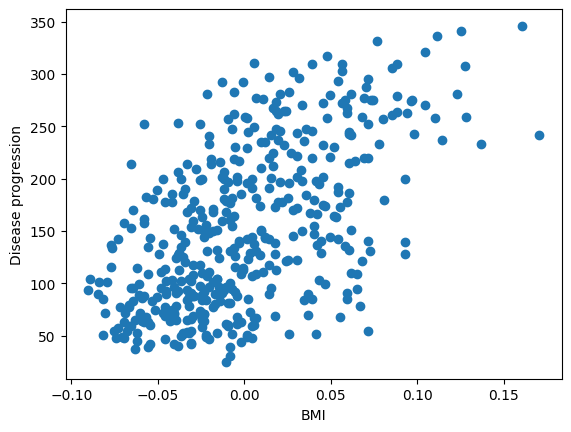

In [3]:
plt.scatter(X_bmi, y)
plt.xlabel("BMI")
plt.ylabel("Disease progression")

In [4]:
inputs = Input(shape=(1,))
output = Dense(1, activation='linear')(inputs)
linear_model = Model(inputs, output)
linear_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
linear_model.compile(optimizer='sgd', loss='mse')

In [6]:
r = linear_model.fit(X_bmi, y, epochs=1000)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24007.9688  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16182.2930 
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11747.2275 
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9226.7637 
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7802.6724 
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6982.6870 
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6512.8086 
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6250.9683 
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6098.5107 
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6013.1646 
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5959.8418 
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5933.3799 
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5913.8345 
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5904.151

Text(0, 0.5, 'Loss')

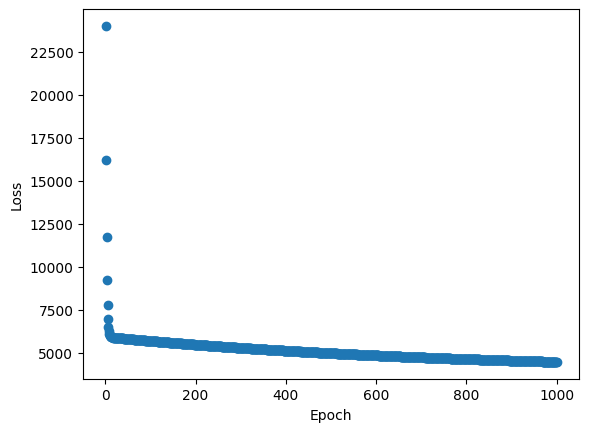

In [7]:
plt.scatter(list(range(1, 1001)), r.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


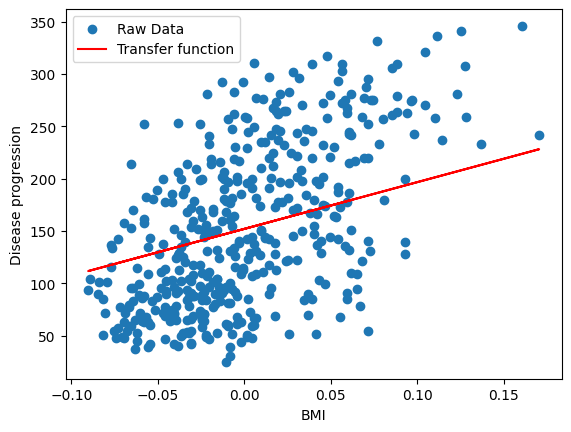

In [8]:
pred = linear_model.predict(X_bmi)

plt.scatter(X_bmi, y, label='Raw Data')
plt.plot(X_bmi, pred, 'r', label="Transfer function")
plt.xlabel("BMI")
plt.ylabel("Disease progression")
plt.legend()

In [9]:
linear_model.save("/Users/lucas/HAAI_lab/Lab-3/linear_model.keras")

In [9]:
linear_model = load_model("/Users/lucas/HAAI_lab/Lab-3/linear_model.keras")
weights = linear_model.layers[1].get_weights()[0]
bias = linear_model.layers[1].get_weights()[1]
print(f"Weights: {repr(weights[0, 0])}\nBias: {repr(bias[0])}")

Weights: np.float32(446.29608)
Bias: np.float32(152.08287)


In [20]:
bmi_samples = np.array([-0.1, -0.07, -0.04, -0.01, 0.02, 0.05, 0.08, 0.11, 0.14, 0.17, 0.2]).reshape(-1, 1)
print(linear_model.predict(bmi_samples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
[[107.45326]
 [120.84215]
 [134.23103]
 [147.6199 ]
 [161.00879]
 [174.39767]
 [187.78656]
 [201.17545]
 [214.56433]
 [227.95322]
 [241.34209]]


In [13]:
X_bmi_bp = X[:, 2:4]

inputs = Input(shape=(2,))
output = Dense(1, activation='linear')(inputs)
linear_model2 = Model(inputs, output)
linear_model2.compile(optimizer='sgd', loss='mse')

r2 = linear_model2.fit(X_bmi_bp, y, epochs=1000)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24009.9336  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16148.5908 
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11716.6660 
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9212.1670 
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7762.7759 
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6951.5396 
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6495.9092 
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6236.8101 
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6086.3169 
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6002.3823 
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5949.4644 
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5919.0454 
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5897.6465 
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5887.253

In [14]:
print(X_bmi_bp.shape)

inputs = Input(shape=(2,))
output = Dense(1, activation='leaky_relu')(inputs)
model = Model(inputs, output)
model.compile(optimizer='sgd', loss='mse')

r3 = model.fit(X_bmi_bp, y, epochs=1000)

(442, 2)
Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 24237.2598  
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 16320.6279
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11822.9053 
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9275.6377   
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7838.2383
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7006.6953
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6535.3740  
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6271.4780
Epoch 9/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6109.2202
Epoch 10/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6015.8047
Epoch 11/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5961.2686  
Epoch 12/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5930.3081  
Epoch 13/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5910.1558  
Epoch 14/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - 